In [2]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict ,Literal
from dotenv import load_dotenv

In [3]:
load_dotenv()
class QuadState(TypedDict):
    a:int
    b:int
    c:int
    equation:str
    discriminant:float
    result:str

In [4]:
def show_equation(state:QuadState):
    equation= f'{state["a"]}x2 + {state["b"]}x + {state["c"]}'
    return {'equation':equation}

def calculate_discriminant(state:QuadState):
    #b2-4ac
    discri=state["b"]**2 -(4* state["a"]*state["c"])
    return {'discriminant':discri}

def real_root(state:QuadState):
    root1= (-state["b"] + state["discriminant"]**0.5)/(2*state["a"])
    root2= (-state["b"] - state["discriminant"]**0.5)/(2*state["a"])
    result=f'The roots are {root1} and {root2}'
    return{'result':result}

def repeted_root(state:QuadState):
    root=(-state["b"])/(2* state["a"])
    result=f'The only repeting root is {root}'
    return {'result':result}

def no_real_root(state:QuadState):
    result=f'No real root'
    return {'result':result}

def check_condition(state:QuadState) -> Literal["real_root","repeted_root","no_real_root"]:
    discri=state["discriminant"]
    if discri>0:
        return "real_root"
    elif discri ==0:
        return "repeted_root"
    else:
        return "no_real_root"
    

In [5]:
graph=StateGraph(QuadState)
graph.add_node('show_equation',show_equation)
graph.add_node('calculate_discriminant',calculate_discriminant)
graph.add_node('real_root',real_root)
graph.add_node('repeted_root',repeted_root)
graph.add_node('no_real_root',no_real_root)


graph.add_edge(START,'show_equation')
graph.add_edge('show_equation','calculate_discriminant')
graph.add_conditional_edges('calculate_discriminant',check_condition)
graph.add_edge('real_root',END)
graph.add_edge('repeted_root',END)
graph.add_edge('no_real_root',END)

work_flow=graph.compile()


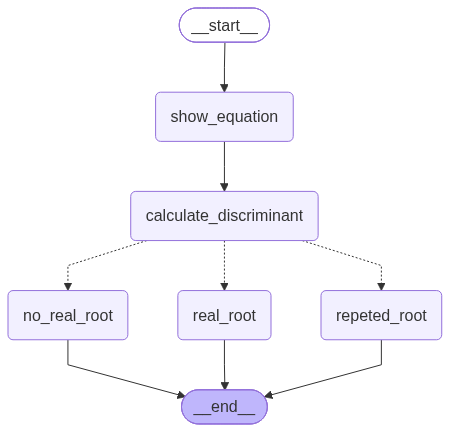

In [6]:
work_flow

In [7]:
intial_state={
    'a':-8,
    'b':5,
    'c':4
}

work_flow.invoke(intial_state)

{'a': -8,
 'b': 5,
 'c': 4,
 'equation': '-8x2 + 5x + 4',
 'discriminant': 153,
 'result': 'The roots are -0.4605823048033113 and 1.0855823048033113'}